# Figure 2
This notebook is meant to be a reproducible implementation of the plotting leading to the complete Figure 2 of the article: panel **A** (example hypnodensity trajectories), **B** (mean PSD), **C** (before/after/late hypnodensity violins) and **D** (standardized LME forest plot). 

Saving of the necessary data to plot in CSV format is also provided for pannels **A** and **B**, while data of pannels **C** and **D** was exported in notebook `02_hypnodensity_analysis.ipynb`. All CSV files should be located in `RESULTS_DIR`.

In [1]:
# Import packages
from pathlib import Path
import os 
import re
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

### Load general information

In [2]:
from dmt_hypnodensities import load_config

config_path = next(
    path.resolve()
    for path in (Path("configs/analysis.yaml"), Path("../configs/analysis.yaml"))
    if path.is_file()
)

config = load_config(config_path)

# Get start and end of each experimental window (pre-infusion, infusion and post-infusion) and convert to minutes for plotting
experimental_windows_min = {
    window.label: (window.start/60, window.end/60) for window in config.experimental_windows
    }
# End of the 'late' experimental window; used to bound the x-axis of the hypnodensity trajectory plots.
max_time_seconds = config.experimental_windows[-1].end

# Paths mirror 02_hypnodensity_analysis.ipynb: persisted hypnodensities/spectra are read from
# RECORDINGS_DIR, and this notebook's derived figure data/figures are saved to RESULTS_DIR/FIGURES_DIR,
# alongside that notebook's LME results.
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'outputs').is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
OUTPUT_ROOT = PROJECT_ROOT / 'outputs'
RUN_DIR = OUTPUT_ROOT / 'gap_sensitivity_000s_gssc_yasa_sleepfm_cpu_v1'
RECORDINGS_DIR = RUN_DIR / 'recordings'
RESULTS_DIR = OUTPUT_ROOT / 'hypnodensity_analysis_000s_gssc_v3'
FIGURES_DIR = RESULTS_DIR / 'figures'
if not RECORDINGS_DIR.is_dir():
    raise FileNotFoundError(f'Recordings directory not found: {RECORDINGS_DIR}')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Get files lists and subject IDs
files_list = os.listdir(RECORDINGS_DIR)

subjects_hypnodensities = sorted({
    match.group(1)
    for f in files_list
    if (match := re.search(r"(P\d+)D\d+_inner_hypnodensities\.parquet$", f))
})
subjects_spectra = sorted({
    match.group(1)
    for f in files_list
    if (match := re.search(r"(P\d+)D\d+_inner_spectra\.parquet$", f))
})
assert subjects_hypnodensities == subjects_spectra, "Mismatch between hypnodensity and spectra subjects"

subjects = subjects_hypnodensities
del subjects_hypnodensities, subjects_spectra

plt.rcParams.update({
    'font.family': 'Arial',
    'font.sans-serif': ['Arial'],
    'font.size': 14,
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 12,
    'svg.fonttype': 'none',
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

c:\Users\Bruna\Documents\Cogmaster\M1\S2\dmt_hypnodensities\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Fig 2. a. Example hypnodensity graph of DMT and Placebo sessions for the same subject

### Main script

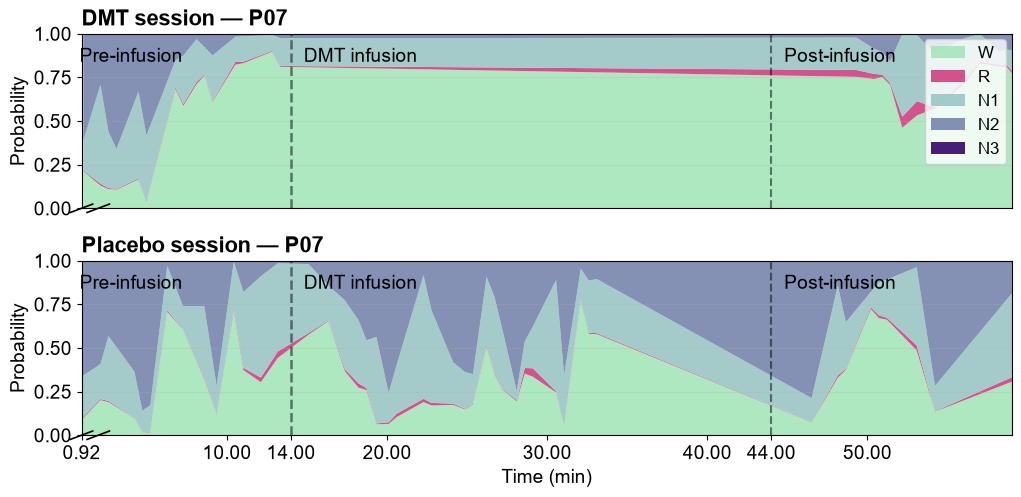

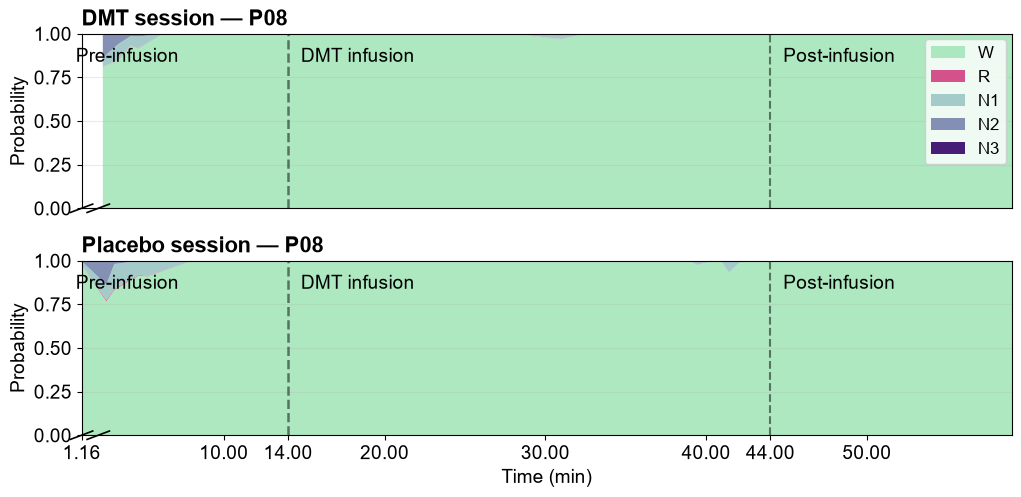

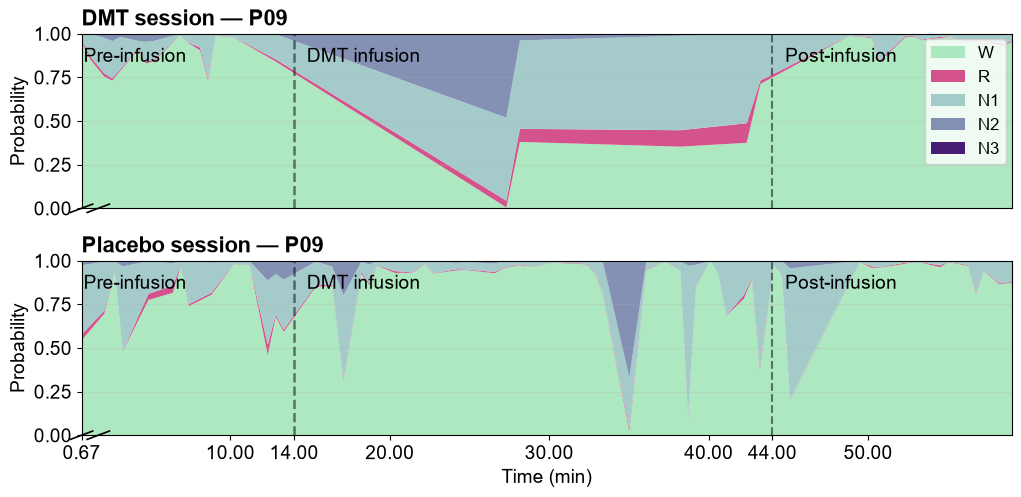

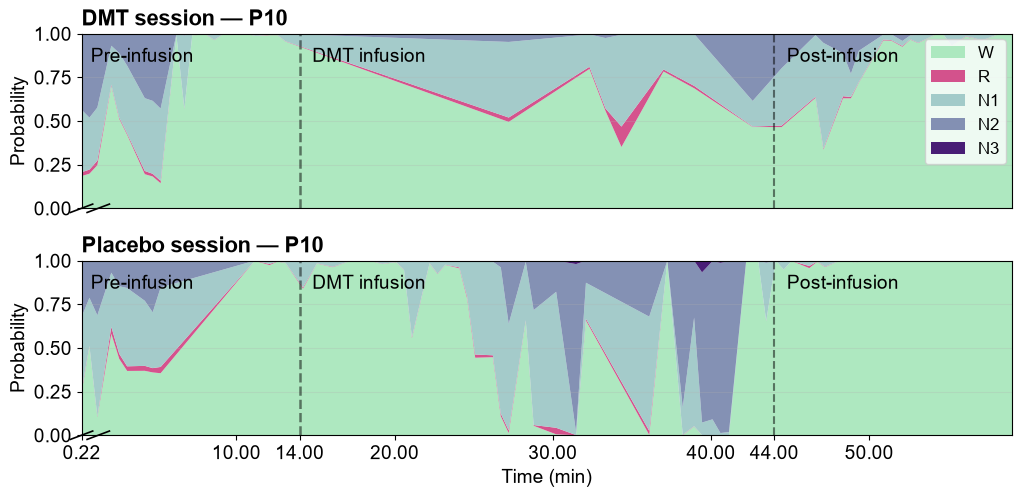

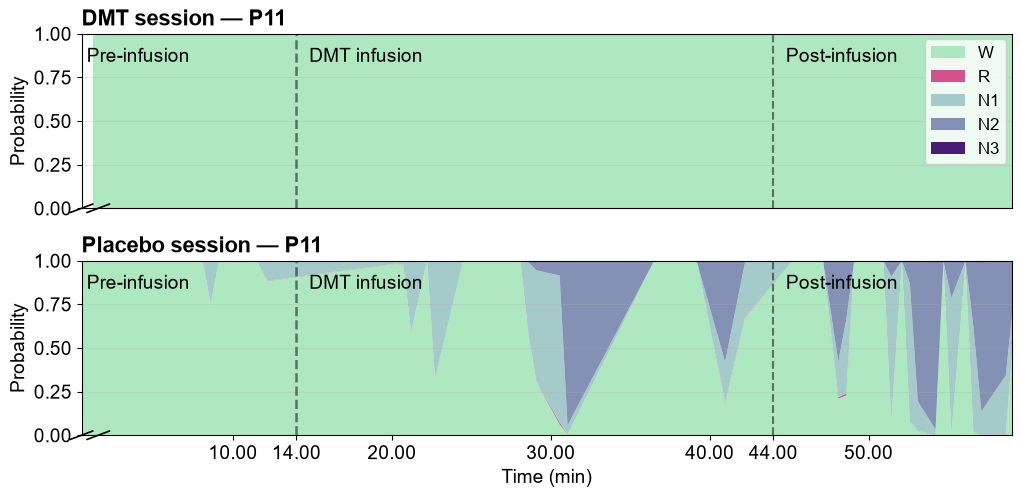

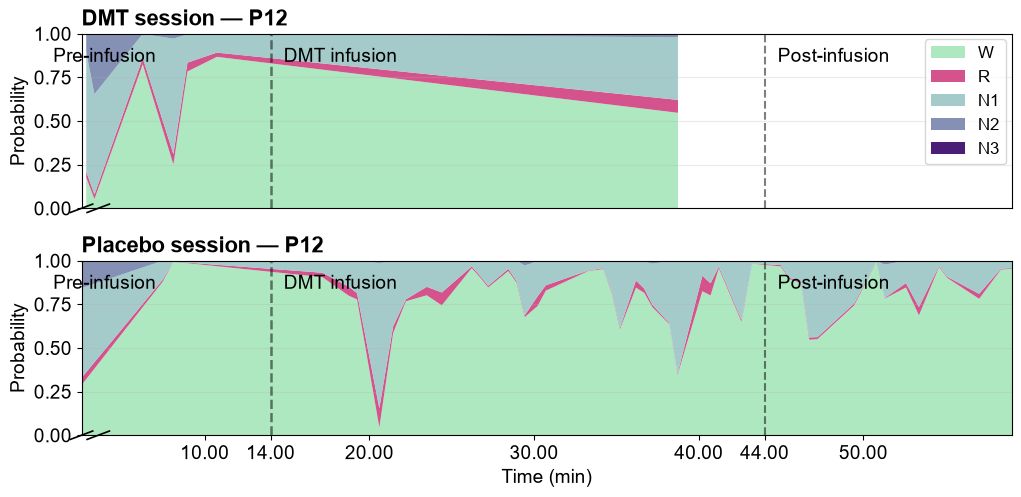

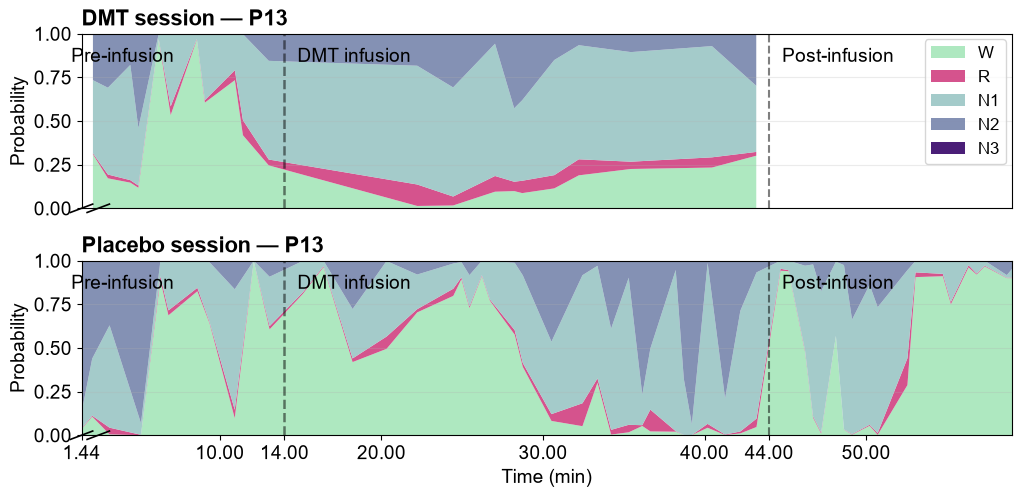

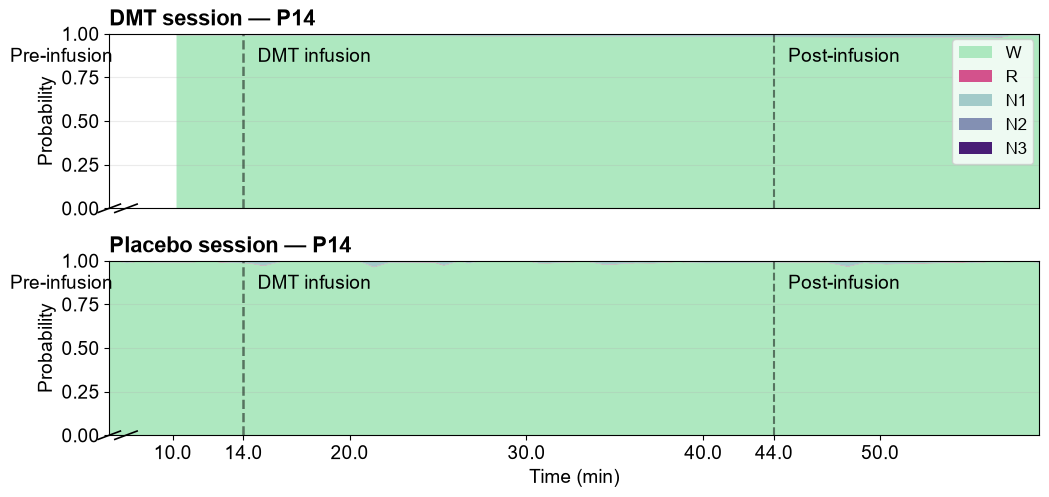

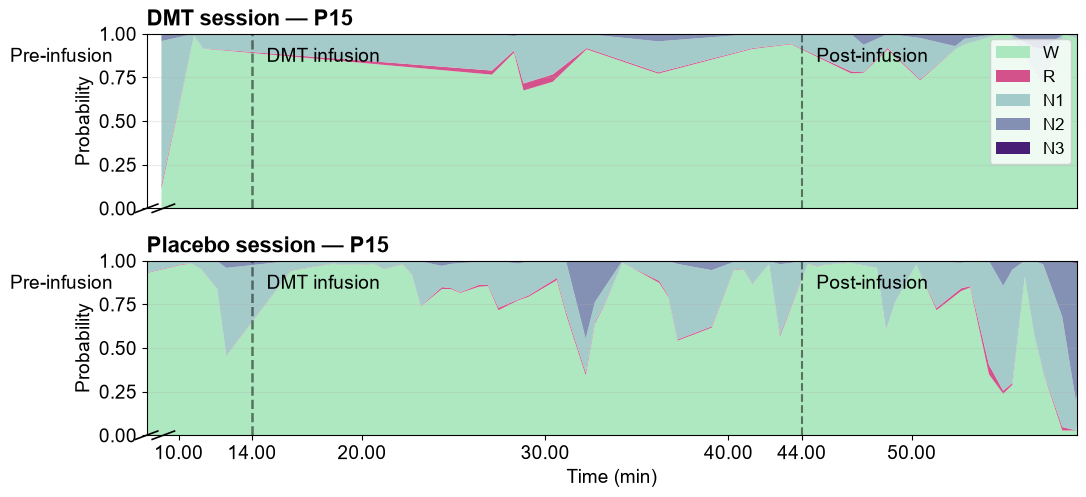

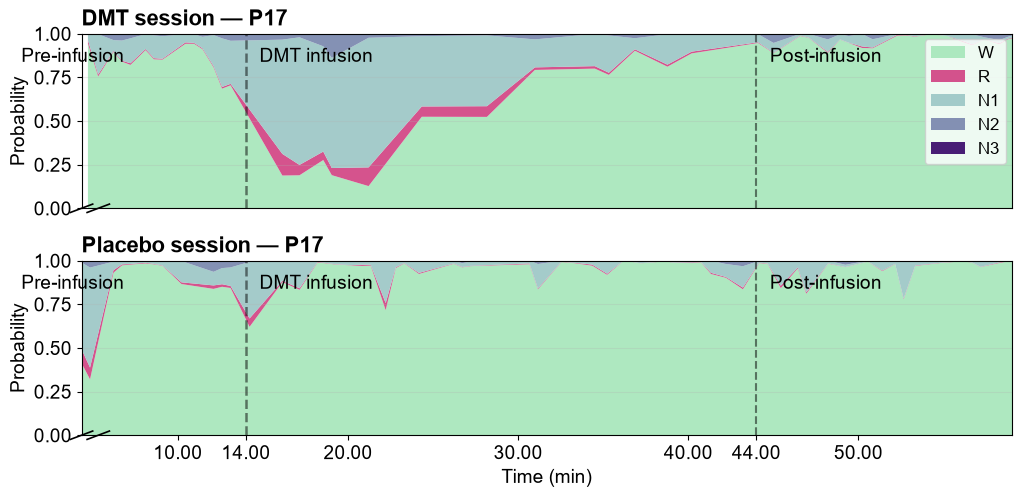

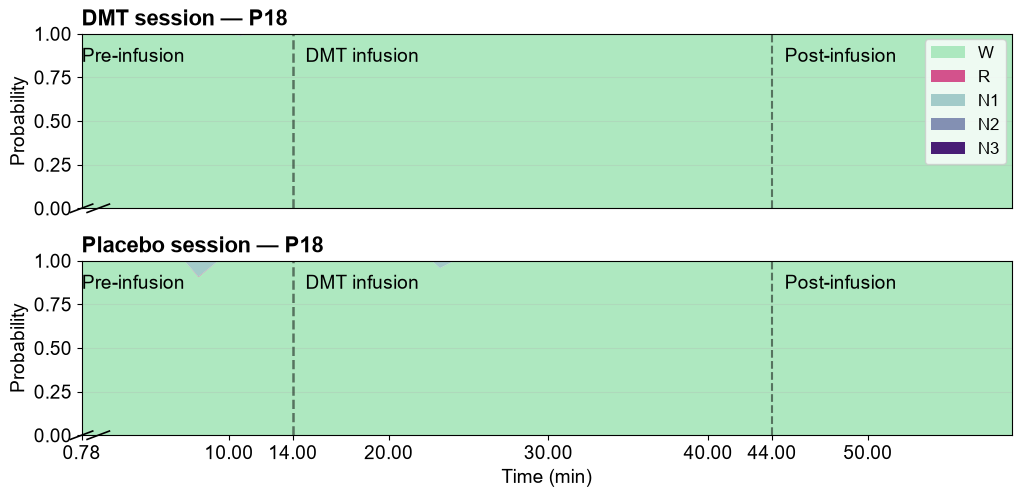

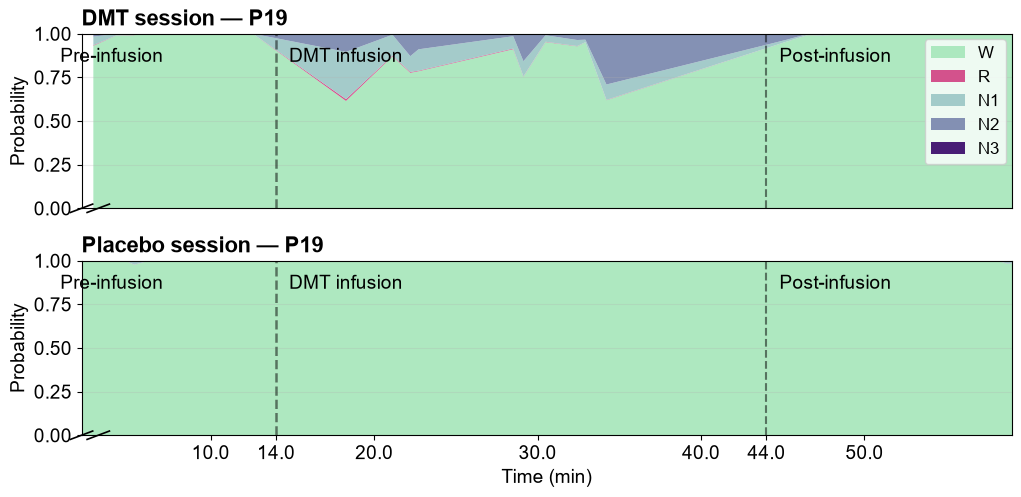

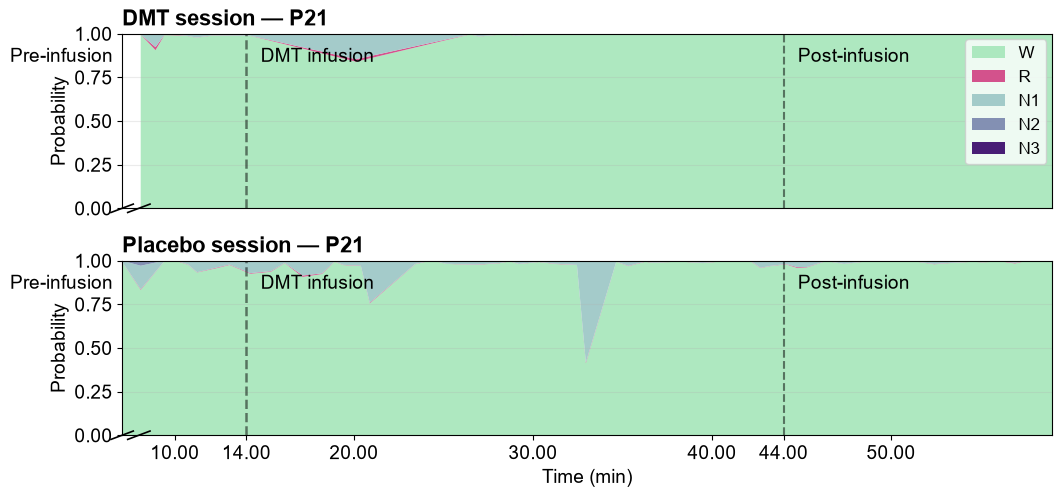

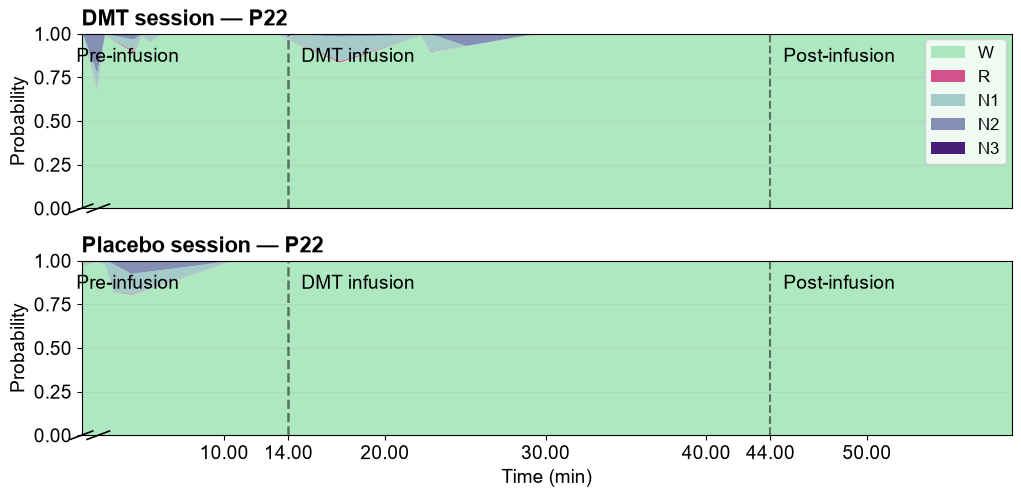

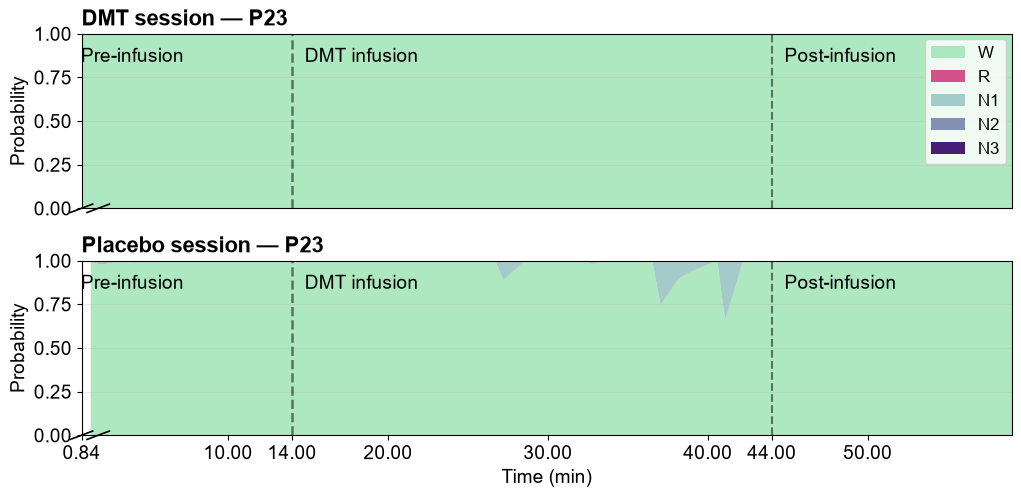

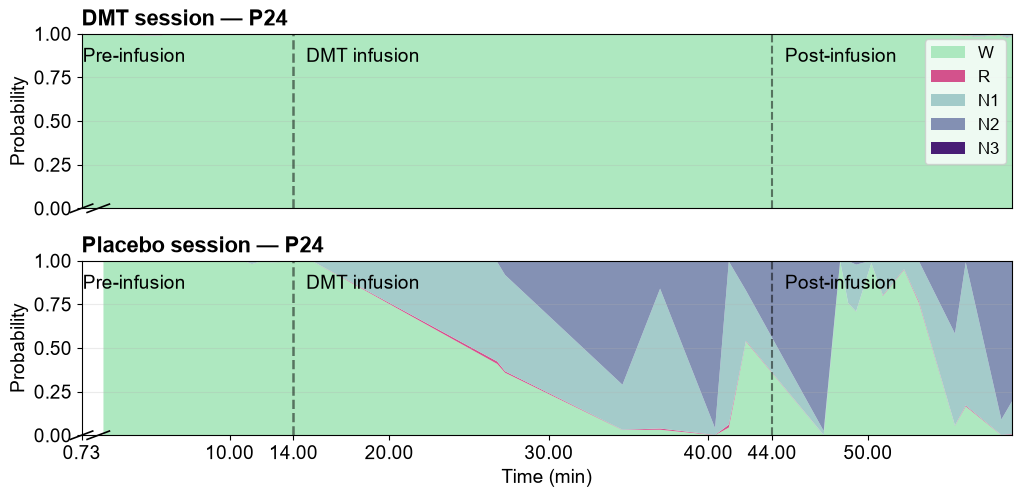

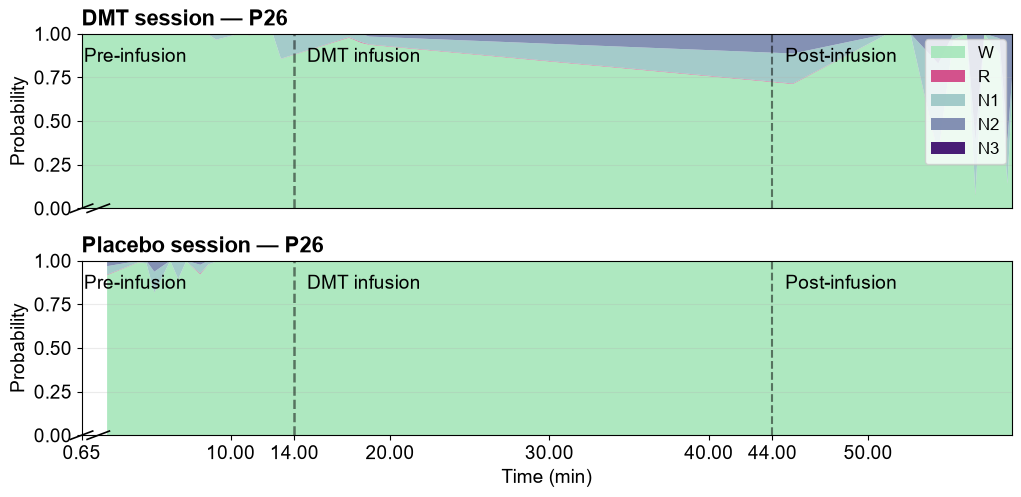

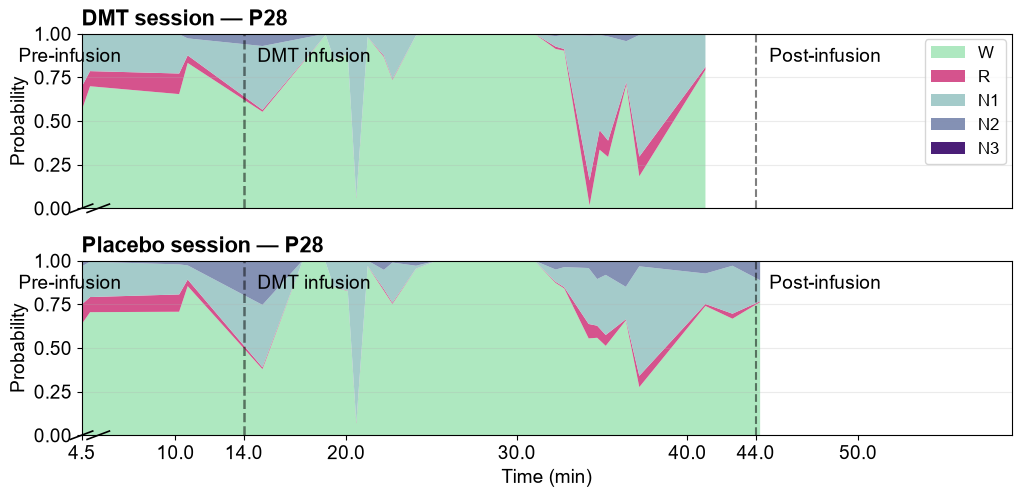

Figure data saved to: c:\Users\Bruna\Documents\Cogmaster\M1\S2\dmt_hypnodensities\outputs\hypnodensity_analysis_000s_gssc_v3\figure2a_hypnodensity_plot_data.csv


,subject,condition,session,recording_id,stager,electrode_selection,absolute_start,time_min,prob_W,prob_R,prob_N1,prob_N2,prob_N3
0,P07,DMT,D5,DMTCI_P07D5_inner,gssc,mean_all_electrodes,61.686,1.028100,0.213033,0.004734,0.169222,0.612364,0.000647
1,P07,DMT,D5,DMTCI_P07D5_inner,gssc,mean_all_electrodes,126.002,2.100033,0.130181,0.010597,0.566149,0.293006,0.000067
2,P07,DMT,D5,DMTCI_P07D5_inner,gssc,mean_all_electrodes,156.002,2.600033,0.109755,0.006022,0.323526,0.560461,0.000237
3,P07,DMT,D5,DMTCI_P07D5_inner,gssc,mean_all_electrodes,186.002,3.100033,0.107020,0.004788,0.227891,0.658381,0.001920
4,P07,DMT,D5,DMTCI_P07D5_inner,gssc,mean_all_electrodes,268.338,4.472300,0.164884,0.005694,0.497358,0.331998,0.000066


In [3]:
subject = 'P09'
# D5 is preferred for DMT; D2 is used automatically when D5 is unavailable.
sessions_by_condition = {'placebo': ('D1',), 'DMT': ('D5', 'D2')}
STAGER = 'gssc'
electrode = None  # e.g. 'Cz'; None averages the selected stager across electrodes
stages = ("W", "R", "N1", "N2", "N3")
palette = ["#360568", "#7785ac", "#9ac6c5",  "#d14081", "#a5e6ba"]
palette.reverse()
colors = dict(zip(stages, palette))

recordings_dir = RECORDINGS_DIR

def load_session_hypnodensity(condition, sessions):
    matches = []
    selected_session = None
    for session in sessions:
        matches = sorted(recordings_dir.glob(f'*{subject}{session}*_hypnodensities.parquet'))
        if len(matches) == 1:
            selected_session = session
            break
        if len(matches) > 1:
            raise FileNotFoundError(
                f'Expected one {condition} file for {subject}{session}; found: {matches}'
            )
    if selected_session is None:
        attempted = ', '.join(f'{subject}{session}' for session in sessions)
        raise FileNotFoundError(f'No {condition} hypnodensity file found; tried: {attempted}')

    data = pd.read_parquet(matches[0])
    required = {'condition', 'stager', 'absolute_start', *(f'prob_{stage}' for stage in stages)}
    missing = required - set(data.columns)
    if missing:
        raise ValueError(f'{matches[0].name} is missing columns: {sorted(missing)}')
    if set(data['condition'].dropna().unique()) != {condition}:
        raise ValueError(f'{matches[0].name} does not contain the expected {condition} session.')

    data = data.loc[data['stager'].astype(str).str.lower().eq(STAGER)].copy()
    if electrode is not None:
        data = data.loc[data['electrode'].eq(electrode)].copy()
    if data.empty:
        raise ValueError(f'No {STAGER} hypnodensities available for {subject} {condition}.')

    probability_columns = [f'prob_{stage}' for stage in stages]
    # One trace per stage: average repeated per-electrode predictions at each epoch.
    trajectory = (
        data
        .groupby('absolute_start', as_index=False)[probability_columns]
        .mean()
        .sort_values('absolute_start')
    )
    trajectory['time_min'] = trajectory['absolute_start'] / 60
    return trajectory, matches[0].stem.removesuffix('_hypnodensities'), selected_session

def draw_start_break(axis, size=0.012):
    """Small diagonal marks on an axis' left edge, flagging that its x-axis does not start at 0."""
    kwargs = dict(transform=axis.transAxes, color='black', clip_on=False, linewidth=1.2)
    axis.plot((-size, size), (-size * 2, size * 2), **kwargs)
    axis.plot((-size + 0.018, size + 0.018), (-size * 2, size * 2), **kwargs)

# Store the exact trajectories used in the figures, for standalone CSV export.
figure_data = []

for subject in subjects:
    fig, axes = plt.subplots(2, 1, figsize=(12, 5.5), sharex=True, sharey=True)

    # Load both sessions before plotting: some sessions are missing their first epoch(s),
    # so both conditions are trimmed to their later, shared start instead of drawing the gap.
    session_trajectories = {
        condition: load_session_hypnodensity(condition, sessions_by_condition[condition])
        for condition in ('DMT', 'placebo')
    }
    common_start_min = max(trajectory['time_min'].min() for trajectory, _, _ in session_trajectories.values())

    for axis, condition in zip(axes, ('DMT', 'placebo')):
        trajectory, recording_id, session = session_trajectories[condition]
        trajectory = trajectory.loc[trajectory['time_min'] >= common_start_min]
        figure_data.append(
            trajectory.assign(
                subject=subject,
                condition=condition,
                session=session,
                recording_id=recording_id,
                stager=STAGER,
                electrode_selection=(electrode or 'mean_all_electrodes'),
            )
        )
        axis.stackplot(
            trajectory['time_min'],
            *[trajectory[f'prob_{stage}'] for stage in stages],
            labels=stages,
            colors=[colors[stage] for stage in stages],
            alpha=0.9,
        )
        if condition == 'placebo':
            condition_title = condition.capitalize()
        else:
            condition_title = condition.upper()
        axis.axvline(x=experimental_windows_min['after'][0], color='k', linestyle='--', linewidth=1.8, alpha=0.5)
        axis.axvline(x=experimental_windows_min['after'][1], color='k', linestyle='--', linewidth=1.5, alpha=0.5)
        axis.text(x=0.8, y=0.92, s='Pre-infusion', rotation=0, va='top', ha='left')
        axis.text(x=experimental_windows_min['after'][0] + 0.8 , y=0.92, s='DMT infusion', rotation=0, va='top', ha='left')
        axis.text(x=experimental_windows_min['after'][1] + 0.8, y=0.92, s='Post-infusion', rotation=0, va='top', ha='left')
        axis.set_title(f'{condition_title} session — {subject}', loc='left', fontweight='bold')
        axis.set_ylabel('Probability')
        axis.set_ylim(0, 1)
        axis.grid(axis='y', alpha=0.25)
        draw_start_break(axis)

    axes[0].tick_params(axis='x', which='both', bottom=False, labelbottom=False)
    axes[-1].set_xlabel('Time (min)')
    axes[-1].set_xticks(sorted({
        round(common_start_min, 2), 10, experimental_windows_min['after'][0], 20, 30, 40,
        experimental_windows_min['after'][1], 50, 60,
    }))
    axes[-1].set_xlim(common_start_min, max_time_seconds / 60)
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, ncols=1, loc='upper right', bbox_to_anchor=(0.902, 0.845))
    fig.subplots_adjust(top=0.84, hspace=0.3)
    plt.show()

# This CSV contains the time and probability values used to draw every Fig. 2a panel.
probability_columns = [f'prob_{stage}' for stage in stages]
figure_data = pd.concat(figure_data, ignore_index=True)[
    [
        'subject', 'condition', 'session', 'recording_id', 'stager',
        'electrode_selection', 'absolute_start', 'time_min', *probability_columns,
    ]
]
figure_data_path = RESULTS_DIR / 'figure2a_hypnodensity_plot_data.csv'
figure_data.to_csv(figure_data_path, index=False)
print(f'Figure data saved to: {figure_data_path}')
display(figure_data.head())

### Fig 2. b. Example Power Spectral Density (PSD) of DMT and Placebo sessions for the same subject

Subjects included: ['P07', 'P08', 'P09', 'P10', 'P11', 'P12', 'P13', 'P14', 'P15', 'P17', 'P18', 'P19', 'P21', 'P22', 'P23', 'P24', 'P26', 'P28']


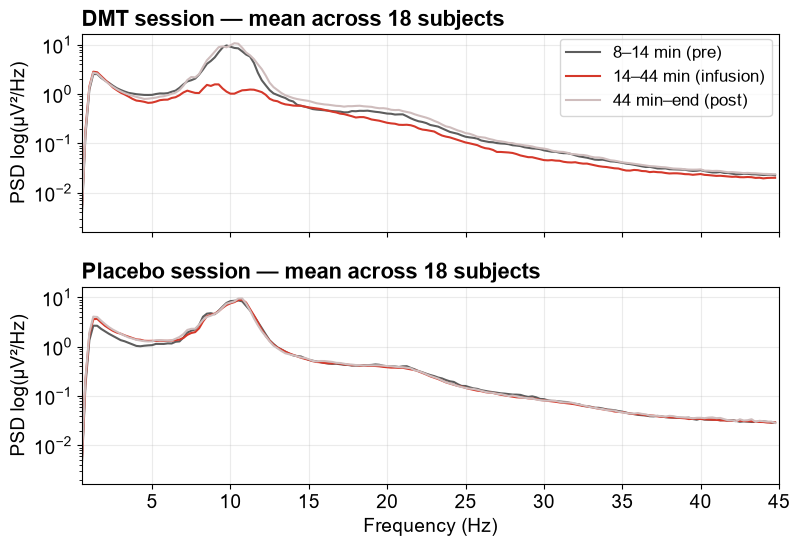

In [14]:
FREQUENCY_RANGE_HZ = (0.5, 45)

# The intervals are [8, 14), [14, 44), and [44, end) minutes.
PHASES = ('8–14 min (pre)', '14–44 min (infusion)', '44 min–end (post)')
PHASE_BINS_MIN = (8, 14, 44, np.inf)
PHASE_COLORS = {'8–14 min (pre)': '#5d5d5dff', '14–44 min (infusion)': '#d5382aff', '44 min–end (post)': '#cfbdbdff'}

def find_psd_recording(subject, condition, sessions, suffix):
    """Find one session, preferring the earlier entries in ``sessions``."""
    for session in sessions:
        matches = sorted(RECORDINGS_DIR.glob(f'*{subject}{session}*{suffix}'))
        if len(matches) == 1:
            return matches[0], session
        if len(matches) > 1:
            raise FileNotFoundError(
                f'Expected one {condition} {suffix} file for {subject}{session}; found: {matches}'
            )
    attempted = ', '.join(f'{subject}{session}' for session in sessions)
    raise FileNotFoundError(f'No {condition} {suffix} file found; tried: {attempted}')

def load_phase_psd(subject, condition):
    spectrum_path, session = find_psd_recording(
        subject, condition, sessions_by_condition[condition], '_spectra.parquet'
    )
    hypnodensity_path, _ = find_psd_recording(
        subject, condition, sessions_by_condition[condition], '_hypnodensities.parquet'
    )

    # Spectra have no timestamps. Hypnodensity rows provide one absolute start time
    # per block/epoch, regardless of stager or electrode.
    epoch_times = pd.read_parquet(
        hypnodensity_path, columns=['block_id', 'epoch', 'absolute_start']
    ).drop_duplicates()
    if epoch_times.duplicated(['block_id', 'epoch']).any():
        raise ValueError(f'A block/epoch maps to more than one time in {hypnodensity_path.name}.')

    spectra = pd.read_parquet(
        spectrum_path, columns=['recording_id', 'block_id', 'epoch', 'electrode', 'frequency_hz', 'power']
    )
    spectra = spectra.merge(epoch_times, on=['block_id', 'epoch'], how='inner', validate='many_to_one')
    spectra['phase'] = pd.cut(
        spectra['absolute_start'] / 60, bins=PHASE_BINS_MIN, labels=PHASES, right=False
    )
    spectra = spectra.loc[
        spectra['phase'].notna() & spectra['frequency_hz'].between(*FREQUENCY_RANGE_HZ)
    ]
    if spectra.empty:
        raise ValueError(f'No spectra from {FREQUENCY_RANGE_HZ} Hz fall within the requested phases.')

    # Mean PSD across all available epochs and electrodes in each phase.
    phase_psd = (
        spectra.groupby(['phase', 'frequency_hz'], observed=True, as_index=False)['power']
        .mean()
        .sort_values(['phase', 'frequency_hz'])
    )
    return phase_psd, spectrum_path.stem.removesuffix('_spectra'), session

print(f"Subjects included: {subjects}")

fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True, sharey=True)

for axis, condition in zip(axes, ("DMT", "placebo")):
    subject_psds = []

    for subject in subjects:
        phase_psd, _, _ = load_phase_psd(subject, condition)

        # Keep one PSD curve per subject before averaging subjects
        subject_psds.append(
            phase_psd.assign(subject=subject)
        )

    all_subject_psds = pd.concat(subject_psds, ignore_index=True)

    mean_phase_psd = (
        all_subject_psds
        .groupby(["phase", "frequency_hz"], observed=True, as_index=False)["power"]
        .mean()
        .sort_values(["phase", "frequency_hz"])
    )

    for phase in PHASES:
        values = mean_phase_psd.loc[
            mean_phase_psd["phase"].eq(phase)
        ]

        axis.plot(
            values["frequency_hz"],
            values["power"],
            color=PHASE_COLORS[phase],
            label=phase,
            linewidth=1.5,
        )

    title = condition.capitalize() if condition == "placebo" else condition
    axis.set_title(
        f"{title} session — mean across {len(subject_psds)} subjects",
        loc="left",
        fontweight="bold",
    )
    axis.set_ylabel("PSD log(µV²/Hz)")
    axis.grid(alpha=0.25)

axes[-1].set_xlabel("Frequency (Hz)")
axes[-1].set_yscale("log")
axes[-1].set_xlim(*FREQUENCY_RANGE_HZ)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper right",
    bbox_to_anchor=(0.901, 0.866),
)

fig.subplots_adjust(top=0.86, hspace=0.28)
plt.show()

In [15]:
# Save the mean and standard deviation PSD values used for Figure 2b

figure2b_data = []

for condition in ("DMT", "placebo"):
    subject_psds = []

    for subject in subjects:
        phase_psd, _, session = load_phase_psd(subject, condition)
        subject_psds.append(phase_psd.assign(subject=subject))

    all_subject_psds = pd.concat(subject_psds, ignore_index=True)

    summary = (
        all_subject_psds
        .groupby(["phase", "frequency_hz"], observed=True)["power"]
        .agg(
            mean_power="mean",
            n_subjects="count",
        )
        .reset_index()
    )

    summary["condition"] = condition
    figure2b_data.append(summary)

figure2b_data = pd.concat(figure2b_data, ignore_index=True)[
    [
        "condition",
        "phase",
        "frequency_hz",
        "mean_power",
        "n_subjects",
    ]
]

figure2b_csv_path = RESULTS_DIR / "figure2b_psd_plot_data.csv"
figure2b_data.to_csv(figure2b_csv_path, index=False)

print(f"Figure 2b data saved to: {figure2b_csv_path}")
display(figure2b_data.head())

Figure 2b data saved to: c:\Users\Bruna\Documents\Cogmaster\M1\S2\dmt_hypnodensities\outputs\hypnodensity_analysis_000s_gssc_v3\figure2b_psd_plot_data.csv


,condition,phase,frequency_hz,mean_power,n_subjects
0,DMT,8–14 min (pre),0.50,0.002476,18
1,DMT,8–14 min (pre),0.75,0.144598,18
2,DMT,8–14 min (pre),1.00,1.231876,18
3,DMT,8–14 min (pre),1.25,2.540805,18
4,DMT,8–14 min (pre),1.50,2.546046,18


### Combined Figure 2 (panels A-D), reproduced from CSVs

One function reproduces the full figure. The function has as only the CSVs exported above (A/B) and by `02_hypnodensity_analysis.ipynb` (C/D: `standardized_lme_forest_panel_data.csv` and `standardized_lme_forest_stats.csv`, saved next to the LME results tables).

Figure saved to: c:\Users\Bruna\Documents\Cogmaster\M1\S2\dmt_hypnodensities\outputs\hypnodensity_analysis_000s_gssc_v3\figures\figure2.png, .svg, .pdf


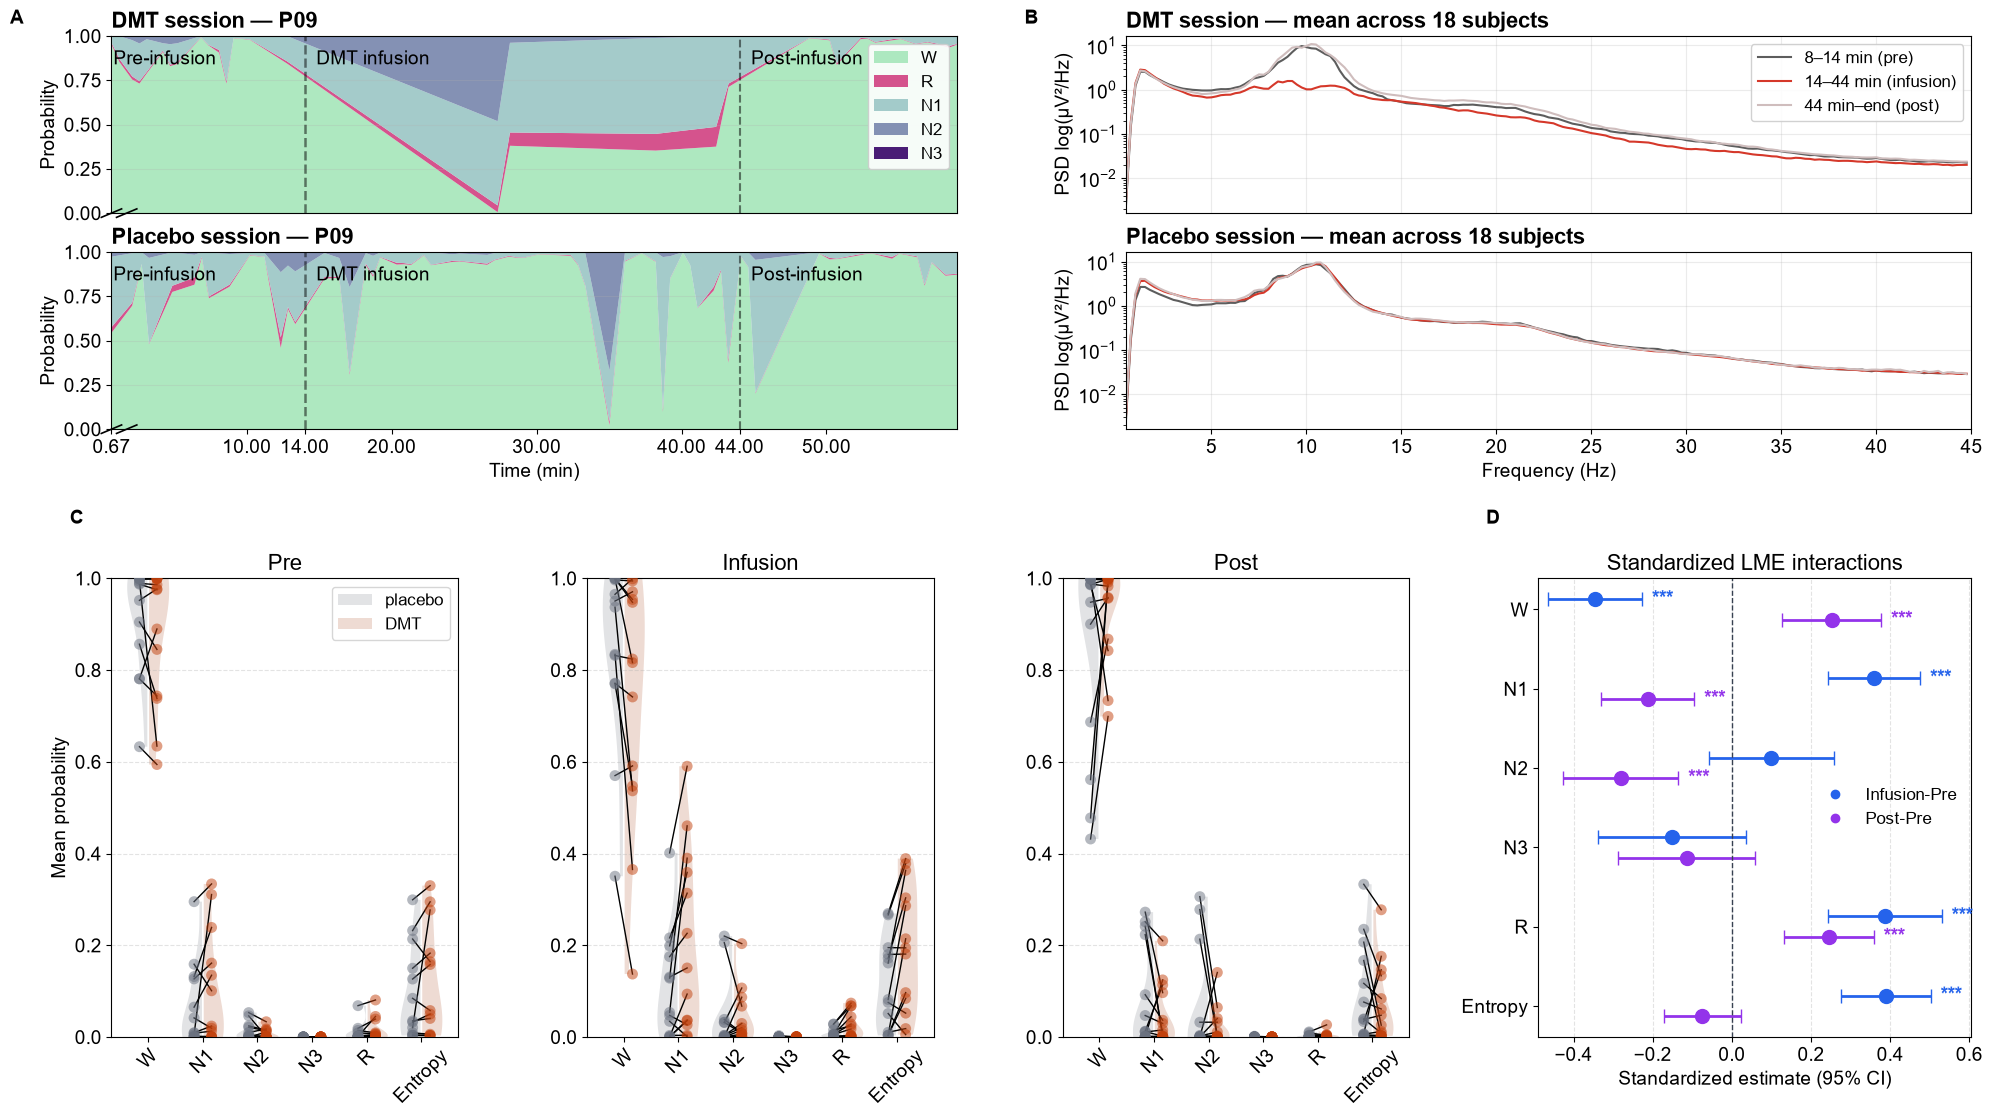

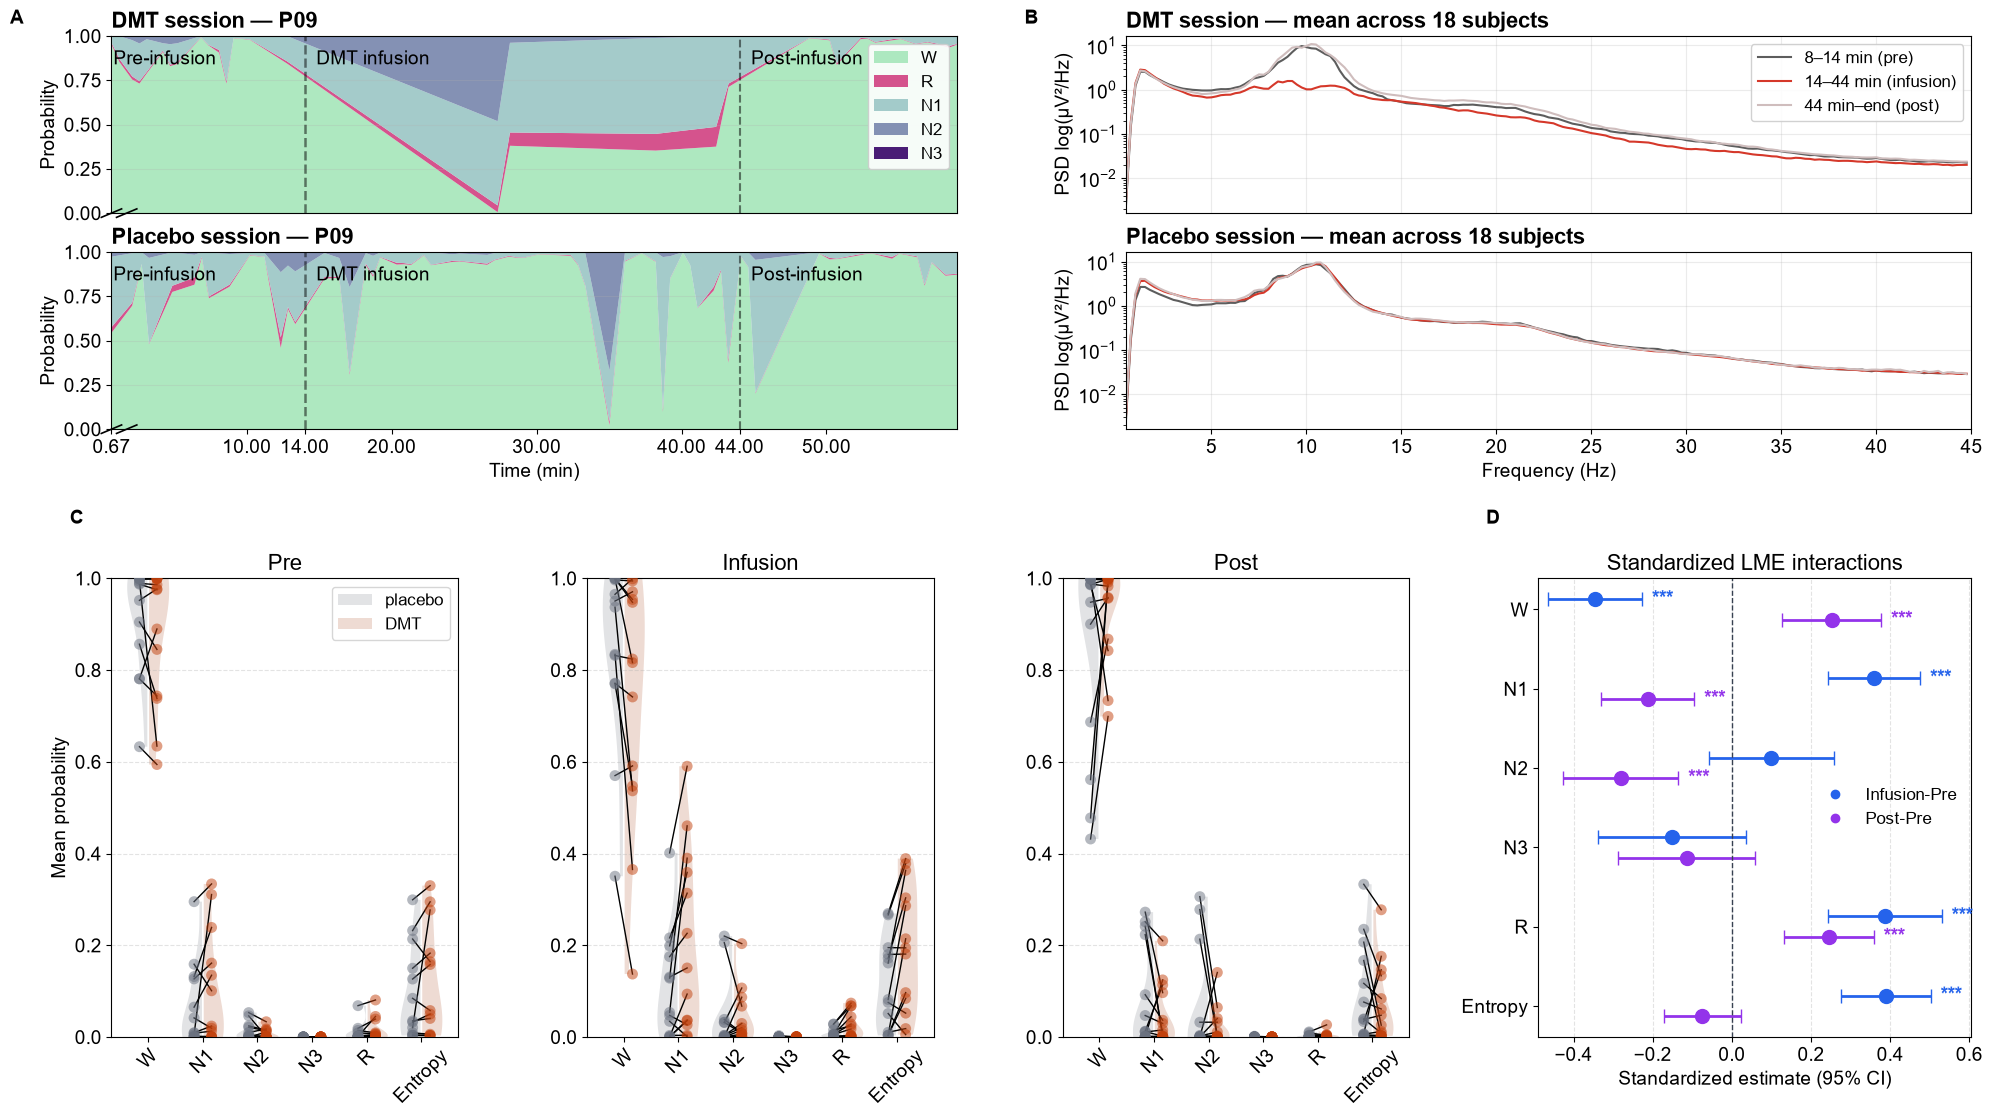

In [16]:
def plot_figure2(
    figure2a_csv_path,
    figure2b_csv_path,
    lme_panel_csv_path,
    lme_stats_csv_path,
    subject,
    save_path=None,
):
    """Reproduce the full four-panel Figure 2 (A-D) directly from exported CSVs."""

    def label_panel(axis, letter):
        axis.text(
            -0.12, 1.15, letter, transform=axis.transAxes,
            fontweight='bold', va='top', ha='left',
        )

    def draw_start_break(axis, size=0.012):
        """Small diagonal marks on an axis' left edge, flagging that its x-axis does not start at 0."""
        kwargs = dict(transform=axis.transAxes, color='black', clip_on=False, linewidth=1.2)
        axis.plot((-size, size), (-size * 2, size * 2), **kwargs)
        axis.plot((-size + 0.018, size + 0.018), (-size * 2, size * 2), **kwargs)

    figure = plt.figure(figsize=(24, 13))
    outer = figure.add_gridspec(2, 1, height_ratios=(6, 7), hspace=0.35)
    top = outer[0].subgridspec(1, 2, wspace=0.2)

    # --- Panel A: example hypnodensity trajectories (DMT / placebo) for one subject ---
    stages_a = ('W', 'R', 'N1', 'N2', 'N3')
    colors_a = dict(zip(stages_a, ['#a5e6ba', '#d14081', '#9ac6c5', '#7785ac', '#360568']))
    probability_columns_a = [f'prob_{stage}' for stage in stages_a]

    panel_a_data = pd.read_csv(figure2a_csv_path)
    required = {'subject', 'condition', 'time_min', *probability_columns_a}
    missing = required - set(panel_a_data.columns)
    if missing:
        raise ValueError(f'{figure2a_csv_path} is missing columns: {sorted(missing)}')
    subject_data = panel_a_data.loc[panel_a_data['subject'].eq(subject)]
    if subject_data.empty:
        raise ValueError(f'{subject} is not present in {figure2a_csv_path}.')
    # The exported CSV already has both conditions trimmed to their shared, possibly non-zero start.
    common_start_min = subject_data['time_min'].min()

    a_gs = top[0].subgridspec(2, 1, hspace=0.22)
    axes_a = [figure.add_subplot(a_gs[0])]
    axes_a.append(figure.add_subplot(a_gs[1], sharex=axes_a[0], sharey=axes_a[0]))
    for axis, condition in zip(axes_a, ('DMT', 'placebo')):
        trajectory = subject_data.loc[subject_data['condition'].eq(condition)].sort_values('time_min')
        if trajectory.empty:
            raise ValueError(f'{subject} has no {condition} data in {figure2a_csv_path}.')
        axis.stackplot(
            trajectory['time_min'],
            *[trajectory[column] for column in probability_columns_a],
            labels=stages_a, colors=[colors_a[stage] for stage in stages_a], alpha=0.9,
        )
        condition_title = condition.capitalize() if condition == 'placebo' else condition
        axis.axvline(x=experimental_windows_min['after'][0], color='k', linestyle='--', linewidth=1.8, alpha=0.5)
        axis.axvline(x=experimental_windows_min['after'][1], color='k', linestyle='--', linewidth=1.5, alpha=0.5)
        axis.text(x=0.8, y=0.92, s='Pre-infusion', va='top', ha='left')
        axis.text(x=experimental_windows_min['after'][0] + 0.8, y=0.92, s='DMT infusion', va='top', ha='left')
        axis.text(x=experimental_windows_min['after'][1] + 0.8, y=0.92, s='Post-infusion', va='top', ha='left')
        axis.set_title(f'{condition_title} session — {subject}', loc='left', fontweight='bold')
        axis.set_ylabel('Probability')
        axis.set_ylim(0, 1)
        axis.grid(axis='y', alpha=0.25)
        draw_start_break(axis)
    axes_a[0].tick_params(axis='x', which='both', bottom=False, labelbottom=False)
    axes_a[-1].set_xlabel('Time (min)')
    axes_a[-1].set_xticks(sorted({
        round(common_start_min, 2), 10, experimental_windows_min['after'][0], 20, 30, 40,
        experimental_windows_min['after'][1], 50, 60,
    }))
    axes_a[-1].set_xlim(common_start_min, max_time_seconds / 60)
    axes_a[0].legend(loc='upper right', framealpha=0.9, ncols=1)
    label_panel(axes_a[0], 'A')

    # --- Panel B: mean PSD by phase (DMT / placebo) ---
    panel_b_data = pd.read_csv(figure2b_csv_path)
    required_b = {'condition', 'phase', 'frequency_hz', 'mean_power'}
    missing = required_b - set(panel_b_data.columns)
    if missing:
        raise ValueError(f'{figure2b_csv_path} is missing columns: {sorted(missing)}')

    b_gs = top[1].subgridspec(2, 1, hspace=0.22)
    axes_b = [figure.add_subplot(b_gs[0])]
    axes_b.append(figure.add_subplot(b_gs[1], sharex=axes_b[0], sharey=axes_b[0]))
    for axis, condition in zip(axes_b, ('DMT', 'placebo')):
        condition_data = panel_b_data.loc[panel_b_data['condition'].eq(condition)]
        for phase in PHASES:
            values = condition_data.loc[condition_data['phase'].eq(phase)].sort_values('frequency_hz')
            axis.plot(values['frequency_hz'], values['mean_power'], color=PHASE_COLORS[phase], label=phase, linewidth=1.5)
        title = condition.capitalize() if condition == 'placebo' else condition
        n_subjects = condition_data['n_subjects'].max() if 'n_subjects' in condition_data else None
        subtitle = f'{title} session — mean across {n_subjects} subjects' if n_subjects is not None else f'{title} session'
        axis.set_title(subtitle, loc='left', fontweight='bold')
        axis.set_ylabel('PSD log(µV²/Hz)')
        axis.set_yscale('log')
        axis.grid(alpha=0.25)
    axes_b[0].tick_params(axis='x', which='both', bottom=False, labelbottom=False)
    axes_b[-1].set_xlabel('Frequency (Hz)')
    axes_b[-1].set_xlim(*FREQUENCY_RANGE_HZ)
    axes_b[0].legend(loc='upper right', framealpha=0.9)
    label_panel(axes_b[0], 'B')

    # --- Panels C (violins) and D (forest): standardized LME interactions ---
    lme_panel_data = pd.read_csv(lme_panel_csv_path)
    lme_stats_data = pd.read_csv(lme_stats_csv_path)

    lme_phases = ('before', 'after', 'late')
    # Display-only labels: the underlying phase/contrast strings in the CSVs are left untouched.
    lme_phase_display = {'before': 'Pre', 'after': 'Infusion', 'late': 'Post'}
    response_order = ['W', 'N1', 'N2', 'N3', 'R', 'Entropy']
    conditions = ('placebo', 'DMT')
    lme_palette = {'placebo': '#6b7280', 'DMT': '#c2410c'}
    point_offsets = {'placebo': -0.16, 'DMT': 0.16}
    contrast_labels = {
        'after': 'After difference-in-differences',
        'late': 'Late difference-in-differences',
    }
    contrast_colors = {contrast_labels['after']: '#2563eb', contrast_labels['late']: '#9333ea'}
    contrast_short = {contrast_labels['after']: 'Infusion-Pre', contrast_labels['late']: 'Post-Pre'}
    contrast_order = {contrast_labels['after']: 0, contrast_labels['late']: 1}

    required_panel_columns = {'subject', 'condition', 'phase', 'response', 'value'}
    missing = required_panel_columns - set(lme_panel_data.columns)
    if missing:
        raise ValueError(f'{lme_panel_csv_path} is missing columns: {sorted(missing)}')
    required_stats_columns = {'response', 'contrast', 'estimate', 'ci95_low', 'ci95_high', 'p_fdr_bh'}
    missing = required_stats_columns - set(lme_stats_data.columns)
    if missing:
        raise ValueError(f'{lme_stats_csv_path} is missing columns: {sorted(missing)}')

    lme_stats_data = lme_stats_data.copy()
    lme_stats_data['response'] = pd.Categorical(lme_stats_data['response'], categories=response_order, ordered=True)
    lme_stats_data['contrast_order'] = lme_stats_data['contrast'].map(contrast_order)
    lme_stats_data = lme_stats_data.sort_values(['response', 'contrast_order']).reset_index(drop=True)
    lme_stats_data['y_position'] = (
        lme_stats_data['response'].cat.codes.astype(float) + lme_stats_data['contrast_order'].map({0: -0.13, 1: 0.13})
    )

    bottom = outer[1].subgridspec(1, 4, width_ratios=(1, 1, 1, 1.25), wspace=0.35)
    axes_c = [figure.add_subplot(bottom[i]) for i in range(3)]
    axis_d = figure.add_subplot(bottom[3])

    for axis, phase in zip(axes_c, lme_phases):
        subset = lme_panel_data.loc[lme_panel_data['phase'].eq(phase)]
        sns.violinplot(
            data=subset, x='response', y='value', hue='condition',
            order=response_order, hue_order=list(conditions), split=True,
            inner=None, palette=lme_palette, cut=0, density_norm='width',
            gap=0.08, fill=True, linewidth=0, ax=axis, edgecolor='none', alpha=0.2,
        )
        axis.set(title=lme_phase_display[phase], xlabel='', ylabel='Mean probability' if axis is axes_c[0] else '', ylim=(0, 1))
        axis.tick_params(axis='x', rotation=45)
        axis.grid(axis='y', linestyle='--', alpha=0.35)
        legend = axis.get_legend()
        if legend is not None:
            (legend.set_title(None) if axis is axes_c[0] else legend.remove())
        for position, response in enumerate(response_order):
            response_subset = subset.loc[subset['response'].eq(response)]
            paired = (
                response_subset.pivot(index='subject', columns='condition', values='value')
                .dropna(subset=list(conditions), how='any')
            )
            for _, paired_subject in paired.iterrows():
                axis.plot(
                    [position + point_offsets['placebo'], position + point_offsets['DMT']],
                    [paired_subject['placebo'], paired_subject['DMT']],
                    color='black', linewidth=1, zorder=3,
                )
            for condition in conditions:
                condition_values = response_subset.loc[response_subset['condition'].eq(condition)]
                axis.scatter(
                    np.full(len(condition_values), position + point_offsets[condition]),
                    condition_values['value'], s=62, color=lme_palette[condition],
                    edgecolor='none', alpha=0.5, zorder=4,
                )

    x_span = lme_stats_data['ci95_high'].max() - lme_stats_data['ci95_low'].min()
    significance_offset = max(0.01, 0.025 * x_span)
    for _, row in lme_stats_data.iterrows():
        y = row['y_position']
        axis_d.errorbar(
            row['estimate'], y,
            xerr=[[row['estimate'] - row['ci95_low']], [row['ci95_high'] - row['estimate']]],
            fmt='o', color=contrast_colors[row['contrast']], ecolor=contrast_colors[row['contrast']],
            capsize=5, markersize=10, linewidth=2,
        )
        if pd.notna(row['p_fdr_bh']) and row['p_fdr_bh'] < 0.001:
            axis_d.text(
                row['ci95_high'] + significance_offset, y, '***',
                color=contrast_colors[row['contrast']],
                va='center', ha='left', fontweight='bold',
            )
    axis_d.set_xlim(
        lme_stats_data['ci95_low'].min() - significance_offset,
        lme_stats_data['ci95_high'].max() + 3 * significance_offset,
    )
    axis_d.axvline(0, color='#374151', linewidth=1, linestyle='--')
    axis_d.set_yticks(np.arange(len(response_order)))
    axis_d.set_yticklabels(response_order)
    axis_d.invert_yaxis()
    axis_d.set_title('Standardized LME interactions')
    axis_d.set_xlabel('Standardized estimate (95% CI)')
    axis_d.grid(axis='x', linestyle='--', alpha=0.35)
    for label, color in contrast_colors.items():
        axis_d.plot([], [], 'o', color=color, label=contrast_short[label])
    axis_d.legend(frameon=False, loc='best')

    label_panel(axes_c[0], 'C')
    label_panel(axis_d, 'D')

    if save_path is not None:
        save_path = Path(save_path)
        figure.savefig(save_path.with_suffix('.png'), dpi=300, bbox_inches='tight')
        figure.savefig(save_path.with_suffix('.svg'), bbox_inches='tight')
        figure.savefig(save_path.with_suffix('.pdf'), bbox_inches='tight')
        print(f'Figure saved to: {save_path.with_suffix(".png")}, .svg, .pdf')

    plt.show()
    return figure

# Example (paths match the CSVs saved above and by 02_hypnodensity_analysis.ipynb's RESULTS_DIR):
plot_figure2(
    figure2a_csv_path=figure_data_path,
    figure2b_csv_path=figure2b_csv_path,
    lme_panel_csv_path=RESULTS_DIR / 'standardized_lme_forest_panel_data.csv',
    lme_stats_csv_path=RESULTS_DIR / 'standardized_lme_forest_stats.csv',
    subject='P09',
    save_path=FIGURES_DIR / 'figure2',
)